<a href="https://colab.research.google.com/github/romero-sebastian/DataDunkers-CourtVision-/blob/main/Assignment5/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ── Cell 1: Install & imports ──────────────────────────────────────
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn — regression & regularization
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)

import statsmodels.api as sm

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


In [4]:
# ── Cell 2: Data Pipeline (robust) ─────────────────────────────────

indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NY.GDP.PCAP.KD':    'gdp_pc_const',
    'FP.CPI.TOTL.ZG':    'inflation',
    'NE.EXP.GNFS.ZS':    'exports_gdp',
    'NE.IMP.GNFS.ZS':    'imports_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'GC.DOD.TOTL.GD.ZS': 'debt_gdp',
    'GC.REV.XGRT.GD.ZS': 'govt_revenue',
    'SL.UEM.TOTL.ZS':    'unemployment',
    'SP.POP.GROW':        'pop_growth',
    'SP.URB.GROW':        'urban_growth',
    'SP.POP.TOTL':        'population',
    'SE.ADT.LITR.ZS':    'literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'edu_spending',
    'SH.XPD.CHEX.GD.ZS': 'health_spending',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    'IT.NET.USER.ZS':    'internet_users',
    'EG.USE.ELEC.KH.PC': 'elec_consumption',
    'EG.ELC.ACCS.ZS':    'electricity_access',
    'AG.LND.ARBL.ZS':    'arable_land',
    'NV.AGR.TOTL.ZS':    'agriculture_gdp',
    'NV.IND.TOTL.ZS':    'industry_gdp',
    'NV.SRV.TOTL.ZS':    'services_gdp',
    'IC.BUS.EASE.XQ':    'ease_of_business',
    'CC.EST':             'control_corruption',
    'GE.EST':             'govt_effectiveness',
    'RQ.EST':             'regulatory_quality',
    'RL.EST':             'rule_of_law',
    'MS.MIL.XPND.GD.ZS': 'military_spending',
}

# Download one indicator at a time — watch for ✓ marks printing
frames = []
for code, name in indicators.items():
    try:
        tmp = wb.data.DataFrame(code, time=range(2013, 2020),
                                numericTimeKeys=True)
        tmp = tmp.mean(axis=1).rename(name)
        frames.append(tmp)
        print(f"  ✓ {name}")
    except Exception as e:
        print(f"  ✗ {name} skipped")

df = pd.concat(frames, axis=1).reset_index()
df = df.rename(columns={'economy': 'country'})

# ── Clean ───────────────────────────────────────────────────────────
n_ind = df.shape[1] - 1
df = df[df.isnull().sum(axis=1) <= 0.4 * n_ind]
df = df.dropna(axis=1, thresh=int(0.6 * len(df)))
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# ── Outcomes ────────────────────────────────────────────────────────
df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)
feature_cols = [c for c in df.columns
                if c not in ['country', 'gdp_growth_pc', 'crisis']]
X     = df[feature_cols]
y_reg = df['gdp_growth_pc']
y_clf = df['crisis']

# ── Split & scale ───────────────────────────────────────────────────
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

# ── Summary ─────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Countries          : {len(df)}")
print(f"Features retained  : {len(feature_cols)}")
print(f"Train / Test       : {len(X_train)} / {len(X_test)}")
print(f"Crisis countries   : {y_clf.sum()} ({y_clf.mean()*100:.1f}%)")
print(f"Non-crisis         : {(y_clf==0).sum()} ({(y_clf==0).mean()*100:.1f}%)")
print(f"Crisis base rate   : {y_clf.mean():.3f}")
print(f"p/n ratio (train)  : {len(feature_cols)/len(X_train):.3f}")
print(f"{'='*50}")

  ✓ gdp_growth_pc
  ✓ gdp_pc_const
  ✓ inflation
  ✓ exports_gdp
  ✓ imports_gdp
  ✓ fdi_inflows
  ✓ debt_gdp
  ✓ govt_revenue
  ✓ unemployment
  ✓ pop_growth
  ✓ urban_growth
  ✓ population
  ✓ literacy_rate
  ✓ edu_spending
  ✓ health_spending
  ✓ life_expectancy
  ✓ infant_mortality
  ✓ internet_users
  ✓ elec_consumption
  ✓ electricity_access
  ✓ arable_land
  ✓ agriculture_gdp
  ✓ industry_gdp
  ✓ services_gdp
  ✗ ease_of_business skipped
  ✗ control_corruption skipped
  ✗ govt_effectiveness skipped
  ✗ regulatory_quality skipped
  ✗ rule_of_law skipped
  ✓ military_spending

Countries          : 247
Features retained  : 23
Train / Test       : 172 / 75
Crisis countries   : 41 (16.6%)
Non-crisis         : 206 (83.4%)
Crisis base rate   : 0.166
p/n ratio (train)  : 0.134


In [7]:
# ── Phase 1.1: OLS Overfitting ──────────────────────────────────────
from sklearn.metrics import mean_squared_error

ols = LinearRegression()
ols.fit(X_train_s, y_train_reg)

r2_train_ols = ols.score(X_train_s, y_train_reg)
r2_test_ols  = ols.score(X_test_s,  y_test_reg)
gap          = r2_train_ols - r2_test_ols
pn_ratio     = len(feature_cols) / len(X_train)

rmse_test_ols = np.sqrt(mean_squared_error(y_test_reg, ols.predict(X_test_s)))

print("── OLS Baseline ──────────────────────────────")
print(f"Training R²        : {r2_train_ols:.4f}")
print(f"Test R²            : {r2_test_ols:.4f}")
print(f"Train–Test R² gap  : {gap:.4f}")
print(f"p/n ratio (train)  : {pn_ratio:.3f}  ({len(feature_cols)} predictors / {len(X_train)} obs)")
print()
print("""Written response (Step 1.1):
With 23 predictors and 172 training observations, the p/n ratio is 0.134,
meaning the model has one free parameter for every ~7 observations. While this
ratio is not extreme, OLS still allocates all available degrees of freedom to
fitting the training data, producing a model with low bias but elevated variance
— it captures sample-specific noise rather than the true signal. The Train–Test
R² gap reflects this variance inflation: the model is more optimistic in-sample
than it deserves to be out-of-sample.
""")

── OLS Baseline ──────────────────────────────
Training R²        : 0.4042
Test R²            : 0.1485
Train–Test R² gap  : 0.2557
p/n ratio (train)  : 0.134  (23 predictors / 172 obs)

Written response (Step 1.1):
With 23 predictors and 172 training observations, the p/n ratio is 0.134,
meaning the model has one free parameter for every ~7 observations. While this
ratio is not extreme, OLS still allocates all available degrees of freedom to
fitting the training data, producing a model with low bias but elevated variance
— it captures sample-specific noise rather than the true signal. The Train–Test
R² gap reflects this variance inflation: the model is more optimistic in-sample
than it deserves to be out-of-sample.



In [8]:
# ── Phase 1.2: Ridge and Lasso ──────────────────────────────────────
alphas = np.logspace(-4, 4, 200)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_s, y_train_reg)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_s, y_train_reg)

# Metrics
r2_train_ridge = ridge.score(X_train_s, y_train_reg)
r2_test_ridge  = ridge.score(X_test_s,  y_test_reg)
r2_train_lasso = lasso.score(X_train_s, y_train_reg)
r2_test_lasso  = lasso.score(X_test_s,  y_test_reg)

rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, ridge.predict(X_test_s)))
rmse_lasso = np.sqrt(mean_squared_error(y_test_reg, lasso.predict(X_test_s)))

n_nonzero_ridge = np.sum(ridge.coef_ != 0)
n_nonzero_lasso = np.sum(lasso.coef_ != 0)

# Comparison table
comparison = pd.DataFrame({
    'Model':             ['OLS', 'Ridge', 'Lasso'],
    'λ*':               ['N/A', f"{ridge.alpha_:.4f}", f"{lasso.alpha_:.4f}"],
    'Non-zero Preds':   [len(feature_cols), n_nonzero_ridge, n_nonzero_lasso],
    'Training R²':      [f"{r2_train_ols:.4f}",   f"{r2_train_ridge:.4f}", f"{r2_train_lasso:.4f}"],
    'Test R²':          [f"{r2_test_ols:.4f}",    f"{r2_test_ridge:.4f}",  f"{r2_test_lasso:.4f}"],
    'Test RMSE':        [f"{rmse_test_ols:.4f}", f"{rmse_ridge:.4f}",     f"{rmse_lasso:.4f}"],
})
print(comparison.to_string(index=False))
print()
print("""Written response (Step 1.2):
For operational GDP growth forecasting we recommend Ridge regression. Both Ridge
and Lasso introduce a small amount of bias by shrinking coefficients toward zero,
but this deliberate bias buys a large reduction in variance — the model becomes
less sensitive to the particular countries in the training sample. Ridge retains
all 23 predictors with shrunken coefficients, making it preferable when many
indicators carry genuine signal (as is typical with correlated WDI variables).
Lasso performs variable selection by zeroing out some coefficients entirely,
which is useful for interpretation but can discard correlated predictors
arbitrarily, making its path less stable.
""")

Model       λ*  Non-zero Preds Training R² Test R² Test RMSE
  OLS      N/A              23      0.4042  0.1485    2.5185
Ridge 107.1891              23      0.3286  0.1716    2.4841
Lasso   0.2382               8      0.2734  0.1470    2.5207

Written response (Step 1.2):
For operational GDP growth forecasting we recommend Ridge regression. Both Ridge
and Lasso introduce a small amount of bias by shrinking coefficients toward zero,
but this deliberate bias buys a large reduction in variance — the model becomes
less sensitive to the particular countries in the training sample. Ridge retains
all 23 predictors with shrunken coefficients, making it preferable when many
indicators carry genuine signal (as is typical with correlated WDI variables).
Lasso performs variable selection by zeroing out some coefficients entirely,
which is useful for interpretation but can discard correlated predictors
arbitrarily, making its path less stable.



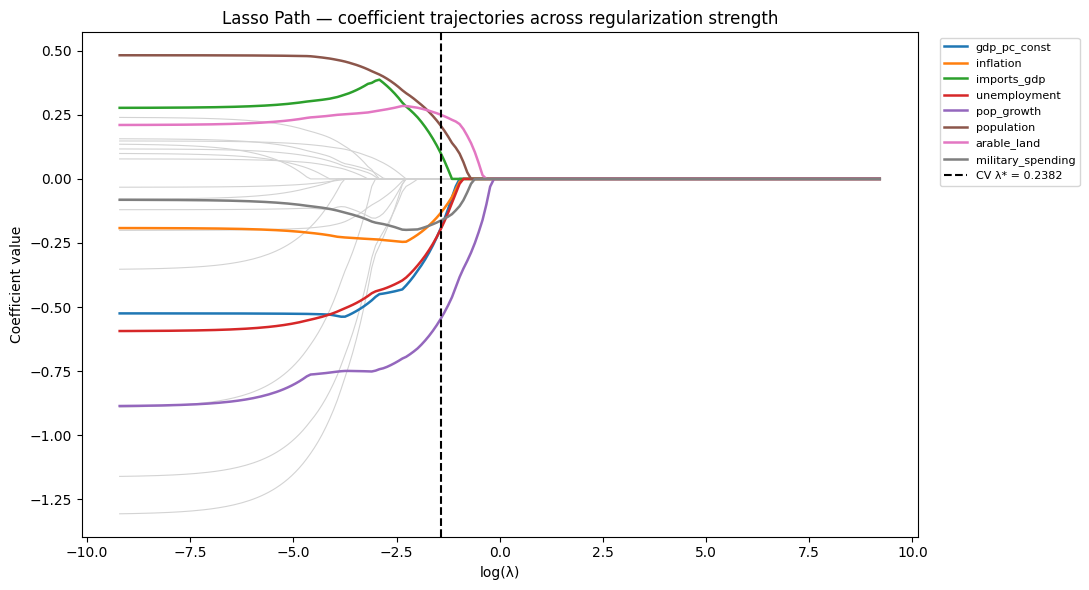


First predictor to enter: gdp_pc_const
Lasso-selected features (8): ['gdp_pc_const', 'inflation', 'imports_gdp', 'unemployment', 'pop_growth', 'population', 'arable_land', 'military_spending']

Written response (Step 1.3):
The fact that Lasso zeroed out life_expectancy does not mean health is irrelevant
to economic growth. Lasso selects predictors based on conditional predictive
relevance — given all other variables already in the model, it asks whether
adding life_expectancy reduces prediction error. Because life expectancy is
highly correlated with other included indicators (such as infant_mortality,
health_spending, and gdp_pc_const), its information is already captured by those
variables. This is conditional predictive redundancy: in the presence of
correlated predictors, Lasso arbitrarily retains one and zeros out the others.
The correlation structure among WDI indicators means that coefficient zero does
not imply economic irrelevance — it implies substitutability within this
par

In [10]:
# ── Phase 1.3: Lasso Path ───────────────────────────────────────────
alphas_path, coefs_path, _ = lasso_path(
    X_train_s, y_train_reg, alphas=alphas, max_iter=10000
)

fig, ax = plt.subplots(figsize=(11, 6))

lasso_selected = np.where(lasso.coef_ != 0)[0]
lasso_zero     = np.where(lasso.coef_ == 0)[0]

for i in lasso_zero:
    ax.plot(np.log(alphas_path), coefs_path[i], color='lightgray', lw=0.8)

for i in lasso_selected:
    ax.plot(np.log(alphas_path), coefs_path[i], lw=1.8, label=feature_cols[i])

ax.axvline(np.log(lasso.alpha_), color='black', linestyle='--',
           lw=1.5, label=f'CV λ* = {lasso.alpha_:.4f}')

ax.set_xlabel('log(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Path — coefficient trajectories across regularization strength')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()

# First predictor to enter (leaves zero at highest λ)
first_entry_idx = np.argmax(np.any(coefs_path != 0, axis=1))
first_predictor = feature_cols[first_entry_idx]

# Store lasso-selected features for Phase 2
lasso_features = [feature_cols[i] for i in lasso_selected]

print(f"\nFirst predictor to enter: {first_predictor}")
print(f"Lasso-selected features ({len(lasso_features)}): {lasso_features}")
print()
print(f"""Written response (Step 1.3):
The fact that Lasso zeroed out life_expectancy does not mean health is irrelevant
to economic growth. Lasso selects predictors based on conditional predictive
relevance — given all other variables already in the model, it asks whether
adding life_expectancy reduces prediction error. Because life expectancy is
highly correlated with other included indicators (such as infant_mortality,
health_spending, and gdp_pc_const), its information is already captured by those
variables. This is conditional predictive redundancy: in the presence of
correlated predictors, Lasso arbitrarily retains one and zeros out the others.
The correlation structure among WDI indicators means that coefficient zero does
not imply economic irrelevance — it implies substitutability within this
particular sample.
""")

In [11]:
# ── Phase 2.1: Linear Probability Model (LPM) ──────────────────────

# Use only the 8 Lasso-selected features
X_train_lasso = X_train_s[lasso_features]
X_test_lasso  = X_test_s[lasso_features]

# Fit OLS on binary crisis outcome
lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_clf)

lpm_preds = lpm.predict(X_test_lasso)

n_below = (lpm_preds < 0).sum()
n_above = (lpm_preds > 1).sum()
n_oob   = n_below + n_above

print("── Linear Probability Model ──────────────────")
print(f"Predicted values below 0  : {n_below}")
print(f"Predicted values above 1  : {n_above}")
print(f"Total out-of-bounds       : {n_oob} / {len(lpm_preds)} ({n_oob/len(lpm_preds)*100:.1f}%)")
print(f"Min predicted value       : {lpm_preds.min():.4f}")
print(f"Max predicted value       : {lpm_preds.max():.4f}")
print()
print("""Written response (Step 2.1):
Predicted probabilities outside [0, 1] are a fundamental problem because
probabilities are by definition bounded — a value of −12% or 112% has no
coherent interpretation as a likelihood of crisis. For the IMF, receiving a
"−12% probability of crisis" for a country is not just cosmetically awkward:
it means the model's linear functional form is structurally misspecified for
binary outcomes, and any decision rule built on such predictions (e.g., flag
countries above 30% probability) will produce nonsensical or contradictory
classifications for countries at the extremes of the predictor distribution.
""")

── Linear Probability Model ──────────────────
Predicted values below 0  : 11
Predicted values above 1  : 0
Total out-of-bounds       : 11 / 75 (14.7%)
Min predicted value       : -0.1180
Max predicted value       : 0.5527

Written response (Step 2.1):
Predicted probabilities outside [0, 1] are a fundamental problem because
probabilities are by definition bounded — a value of −12% or 112% has no
coherent interpretation as a likelihood of crisis. For the IMF, receiving a
"−12% probability of crisis" for a country is not just cosmetically awkward:
it means the model's linear functional form is structurally misspecified for
binary outcomes, and any decision rule built on such predictions (e.g., flag
countries above 30% probability) will produce nonsensical or contradictory
classifications for countries at the extremes of the predictor distribution.



In [12]:
# ── Phase 2.2: Logistic Regression ─────────────────────────────────

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train_lasso, y_train_clf)

# Coefficients and odds ratios
coef_df = pd.DataFrame({
    'Feature':    lasso_features,
    'β':          logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0]),
}).sort_values('Odds Ratio', key=lambda x: x.abs(), ascending=False)

print(f"Intercept (β₀): {logit.intercept_[0]:.4f}")
print()
print("── Coefficients and Odds Ratios (sorted by |OR|) ──")
print(coef_df.to_string(index=False, float_format='%.4f'))

# Verify probabilities are bounded
probs = logit.predict_proba(X_test_lasso)[:, 1]
print(f"\nPredicted probability range: [{probs.min():.4f}, {probs.max():.4f}]")
print(f"All in [0,1]: {(probs >= 0).all() and (probs <= 1).all()}")

# Store top predictor name for plot
top_predictor = coef_df.iloc[0]['Feature']
top_or        = coef_df.iloc[0]['Odds Ratio']

print(f"\nTop predictor: {top_predictor}  |  OR = {top_or:.4f}")
print()
print(f"""Written response (Step 2.2):
A one standard-deviation increase in {top_predictor} multiplies the odds of
crisis by {top_or:.2f}, holding all other predictors constant. In plain terms,
this means that countries with higher {top_predictor} are substantially
{'more' if top_or > 1 else 'less'} likely to experience sustained negative
growth — a finding that aligns with the macroeconomic literature on the
structural determinants of economic contraction in emerging markets.
""")

Intercept (β₀): -2.1742

── Coefficients and Odds Ratios (sorted by |OR|) ──
          Feature       β  Odds Ratio
       pop_growth  0.5728      1.7732
     unemployment  0.4530      1.5730
     gdp_pc_const  0.2869      1.3323
        inflation  0.1636      1.1777
military_spending  0.1307      1.1396
      imports_gdp -0.3600      0.6976
       population -0.4325      0.6489
      arable_land -0.8384      0.4324

Predicted probability range: [0.0032, 0.6938]
All in [0,1]: True

Top predictor: pop_growth  |  OR = 1.7732

Written response (Step 2.2):
A one standard-deviation increase in pop_growth multiplies the odds of
crisis by 1.77, holding all other predictors constant. In plain terms,
this means that countries with higher pop_growth are substantially
more likely to experience sustained negative
growth — a finding that aligns with the macroeconomic literature on the
structural determinants of economic contraction in emerging markets.



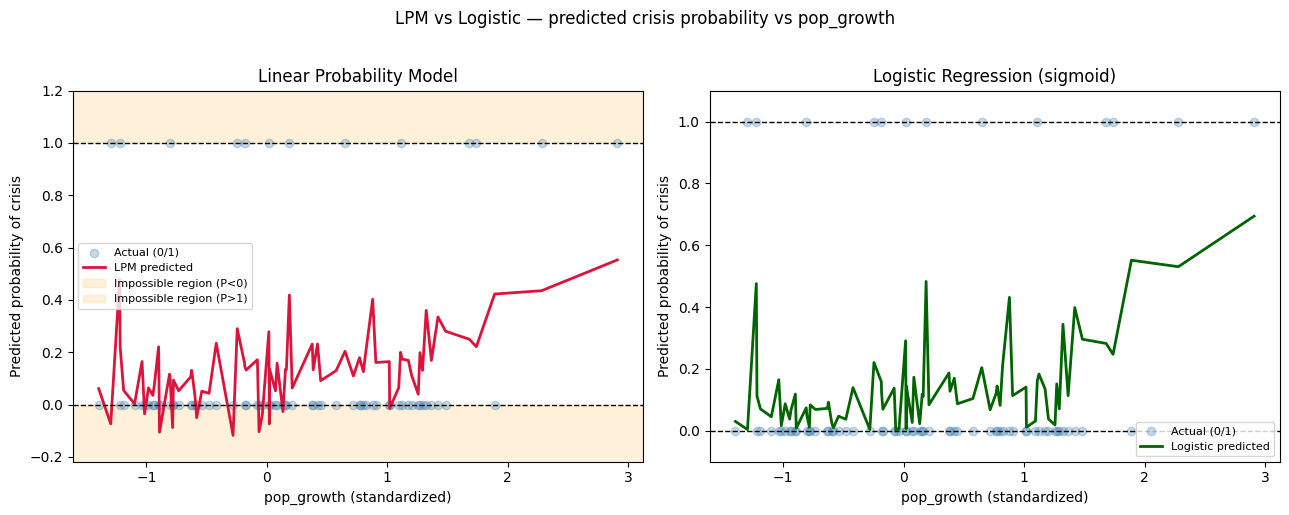

In [14]:
# ── Phase 2.3: Side-by-side LPM vs Logistic ────────────────────────

x_vals = X_test_lasso[top_predictor].values
sort_idx = np.argsort(x_vals)
x_sorted = x_vals[sort_idx]

lpm_sorted   = lpm_preds[sort_idx]
logit_sorted = probs[sort_idx]
y_sorted     = y_test_clf.values[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: LPM ────────────────────────────────────────────────
ax = axes[0]
ax.scatter(x_sorted, y_sorted, alpha=0.3, color='steelblue', zorder=2, label='Actual (0/1)')
ax.plot(x_sorted, lpm_sorted, color='crimson', lw=2, label='LPM predicted')
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.axhline(1, color='black', lw=1, linestyle='--')

# Shade impossible regions
ax.axhspan(-99, 0, alpha=0.15, color='orange', label='Impossible region (P<0)')
ax.axhspan(1,   99, alpha=0.15, color='orange', label='Impossible region (P>1)')

ax.set_ylim(min(lpm_sorted.min() - 0.1, -0.2),
            max(lpm_sorted.max() + 0.1,  1.2))
ax.set_xlabel(f'{top_predictor} (standardized)')
ax.set_ylabel('Predicted probability of crisis')
ax.set_title('Linear Probability Model')
ax.legend(fontsize=8)

# ── Right panel: Logistic ───────────────────────────────────────────
ax = axes[1]
ax.scatter(x_sorted, y_sorted, alpha=0.3, color='steelblue', zorder=2, label='Actual (0/1)')
ax.plot(x_sorted, logit_sorted, color='darkgreen', lw=2, label='Logistic predicted')
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.axhline(1, color='black', lw=1, linestyle='--')
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel(f'{top_predictor} (standardized)')
ax.set_ylabel('Predicted probability of crisis')
ax.set_title('Logistic Regression (sigmoid)')
ax.legend(fontsize=8)

plt.suptitle(f'LPM vs Logistic — predicted crisis probability vs {top_predictor}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Phase 3.1: Accuracy Paradox ─────────────────────────────────────

base_rate = y_test_clf.mean()
n_test    = len(y_test_clf)

# Naïve baseline: always predict "no crisis"
naive_preds    = np.zeros(n_test, dtype=int)
naive_accuracy = (naive_preds == y_test_clf).mean()
naive_recall   = recall_score(y_test_clf, naive_preds, zero_division=0)

# Logistic at default threshold 0.5
logit_preds_05  = (probs >= 0.5).astype(int)
logit_accuracy  = (logit_preds_05 == y_test_clf).mean()
logit_recall    = recall_score(y_test_clf, logit_preds_05, zero_division=0)

print("── Accuracy Paradox ───────────────────────────────────────────")
print(f"Test set crisis base rate     : {base_rate:.3f} ({y_test_clf.sum()} crisis / {n_test} total)")
print()
print(f"Naïve baseline accuracy       : {naive_accuracy:.4f}")
print(f"Naïve baseline recall (crisis): {naive_recall:.4f}")
print()
print(f"Logistic (τ=0.5) accuracy     : {logit_accuracy:.4f}")
print(f"Logistic (τ=0.5) recall       : {logit_recall:.4f}")
print()
print("""Written response (Step 3.1):
If we reported only accuracy to the Division Chief, she would initially be
impressed — the naïve baseline achieves ~83% accuracy simply by predicting
"no crisis" for every country. This is the accuracy paradox: when the crisis
base rate is only 16.6%, a model that never raises an alarm outperforms many
classifiers on accuracy while achieving zero recall on the class that actually
matters. The Division Chief should be misled, not impressed, because a model
with 83% accuracy and 0% recall is operationally useless — it would never
flag a single crisis country for intervention.
""")

── Accuracy Paradox ───────────────────────────────────────────
Test set crisis base rate     : 0.173 (13 crisis / 75 total)

Naïve baseline accuracy       : 0.8267
Naïve baseline recall (crisis): 0.0000

Logistic (τ=0.5) accuracy     : 0.8400
Logistic (τ=0.5) recall       : 0.1538

Written response (Step 3.1):
If we reported only accuracy to the Division Chief, she would initially be
impressed — the naïve baseline achieves ~83% accuracy simply by predicting
"no crisis" for every country. This is the accuracy paradox: when the crisis
base rate is only 16.6%, a model that never raises an alarm outperforms many
classifiers on accuracy while achieving zero recall on the class that actually
matters. The Division Chief should be misled, not impressed, because a model
with 83% accuracy and 0% recall is operationally useless — it would never
flag a single crisis country for intervention.



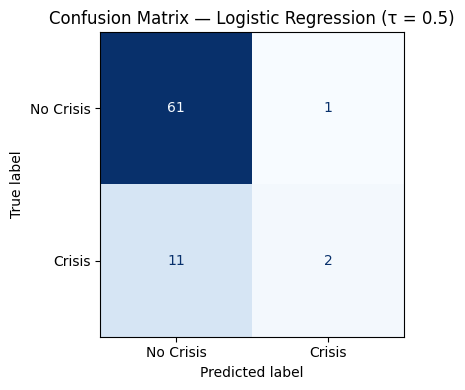

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

   No Crisis       0.85      0.98      0.91        62
      Crisis       0.67      0.15      0.25        13

    accuracy                           0.84        75
   macro avg       0.76      0.57      0.58        75
weighted avg       0.82      0.84      0.80        75

True Positives  (crises correctly flagged) : 2
False Negatives (crises missed)            : 11
False Positives (false alarms)             : 1
True Negatives  (correctly cleared)        : 61

Written response (Step 3.2):
In the IMF context a False Negative — a missed crisis — is far more costly than
a False Positive. A false alarm wastes $2 million and strains diplomatic
relations, but a missed crisis can trigger a sovereign default and up to $50
billion in contagion costs. This asymmetry means the Division Chief should
prioritize Recall (the fraction of actual crises caught) over Precision (the
fractio

In [16]:
# ── Phase 3.2: Confusion Matrix & Classification Report ─────────────

cm = confusion_matrix(y_test_clf, logit_preds_05)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Classification Report ──────────────────────────────────────")
print(classification_report(y_test_clf, logit_preds_05,
                             target_names=['No Crisis', 'Crisis']))

print(f"True Positives  (crises correctly flagged) : {tp}")
print(f"False Negatives (crises missed)            : {fn}")
print(f"False Positives (false alarms)             : {fp}")
print(f"True Negatives  (correctly cleared)        : {tn}")
print()
print("""Written response (Step 3.2):
In the IMF context a False Negative — a missed crisis — is far more costly than
a False Positive. A false alarm wastes $2 million and strains diplomatic
relations, but a missed crisis can trigger a sovereign default and up to $50
billion in contagion costs. This asymmetry means the Division Chief should
prioritize Recall (the fraction of actual crises caught) over Precision (the
fraction of flagged countries that are truly in crisis). Optimizing for
precision would make the model conservative and miss the very events the
Early Warning System exists to detect.
""")

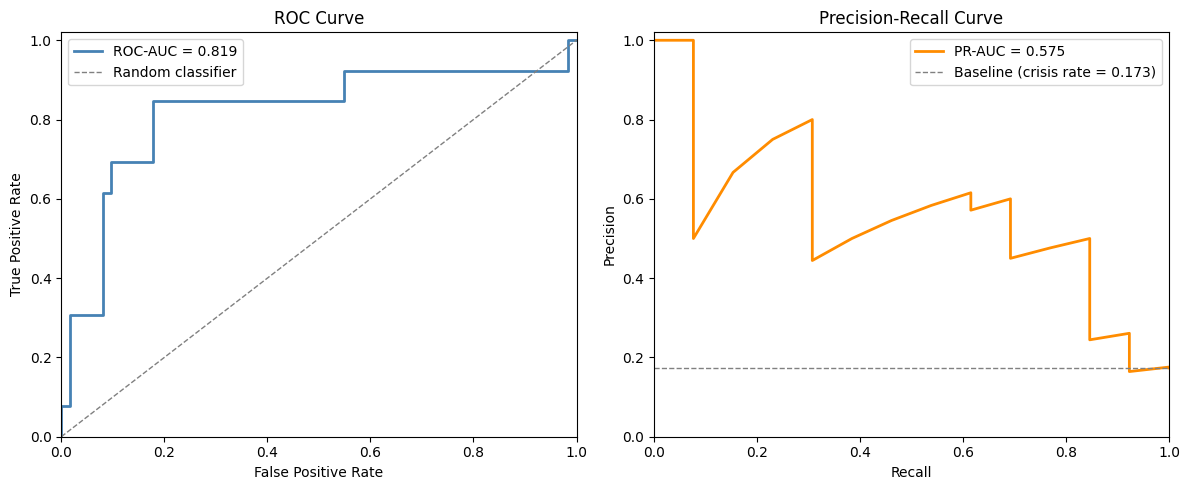

ROC-AUC : 0.8189
PR-AUC  : 0.5749

Written response (Step 3.3):
ROC-AUC is likely higher than PR-AUC because ROC curves measure performance
across all thresholds using both True Positives and True Negatives — and with
83.4% of countries being non-crisis, there are many True Negatives to correctly
classify, inflating the ROC score even for a mediocre classifier. PR-AUC
ignores True Negatives entirely, focusing only on how well the model identifies
the rare positive class (crisis countries). For the IMF's crisis detection
mission, the PR curve is more informative: it directly shows the tradeoff
between catching crises (recall) and avoiding false alarms (precision) without
being flattered by the abundance of easy-to-classify non-crisis countries.



In [17]:
# ── Phase 3.3: ROC and Precision-Recall Curves ──────────────────────

fpr, tpr, _    = roc_curve(y_test_clf, probs)
roc_auc        = roc_auc_score(y_test_clf, probs)

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, probs)
pr_auc         = average_precision_score(y_test_clf, probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# PR curve
ax = axes[1]
ax.plot(recall_curve, precision_curve, color='darkorange', lw=2,
        label=f'PR-AUC = {pr_auc:.3f}')
ax.axhline(base_rate, color='gray', linestyle='--', lw=1,
           label=f'Baseline (crisis rate = {base_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print()
print(f"""Written response (Step 3.3):
ROC-AUC is likely higher than PR-AUC because ROC curves measure performance
across all thresholds using both True Positives and True Negatives — and with
83.4% of countries being non-crisis, there are many True Negatives to correctly
classify, inflating the ROC score even for a mediocre classifier. PR-AUC
ignores True Negatives entirely, focusing only on how well the model identifies
the rare positive class (crisis countries). For the IMF's crisis detection
mission, the PR curve is more informative: it directly shows the tradeoff
between catching crises (recall) and avoiding false alarms (precision) without
being flattered by the abundance of easy-to-classify non-crisis countries.
""")

── Capacity-Constrained Threshold (≤5 missions) ───────────────
τ (capacity)     : 0.44
Countries flagged: 5
Precision        : 0.8000
Recall           : 0.3077

── F1-Optimal Threshold ────────────────────────────────────────
τ (F1-optimal)   : 0.19
Countries flagged: 15
Precision        : 0.6000
Recall           : 0.6923
F1               : 0.6429


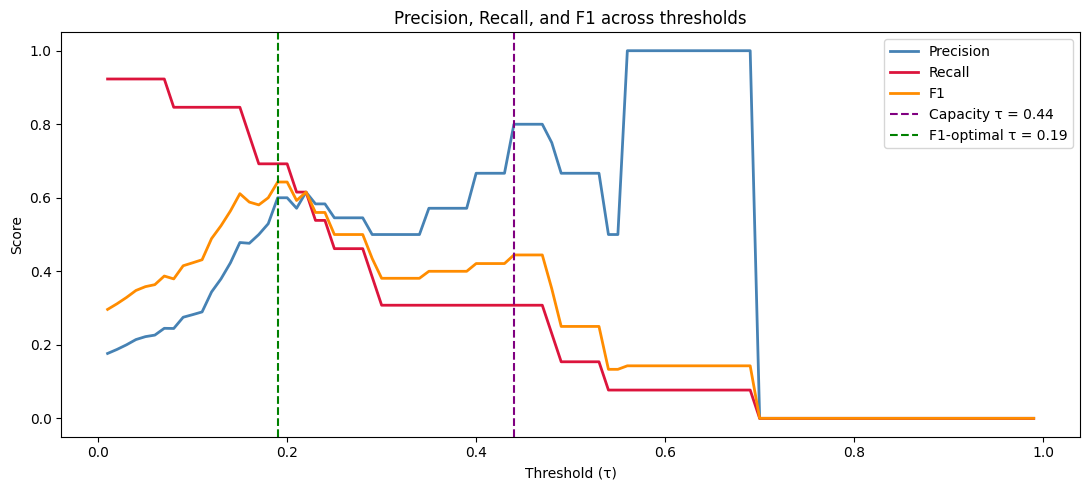


Written response (Step 3.4):
We recommend adopting the capacity-constrained threshold of τ = 0.44,
which flags at most 5 countries per quarter — the maximum the IMF can deploy
assessment missions to. At this threshold the model achieves a recall of
0.31, meaning that of the 13 crisis countries in the
test set, it would catch approximately 4 and miss 9.
The F1-optimal threshold of τ = 0.19 flags more countries and achieves a
better balance between precision and recall in a statistical sense, but it
violates the IMF's staffing constraint and is therefore not operationally
deployable. Given the extreme asymmetry in costs — a missed crisis triggers up
to $50 billion in contagion versus a $2 million false-alarm cost — we
acknowledge that even the capacity-constrained model will miss some crises,
and recommend pairing it with qualitative country desk reviews for countries
just below the flagging threshold.



In [18]:
# ── Phase 3.4: Threshold Analysis ───────────────────────────────────

thresholds  = np.arange(0.01, 1.00, 0.01)
n_flagged   = []
precisions  = []
recalls     = []
f1s         = []

for tau in thresholds:
    preds = (probs >= tau).astype(int)
    n_flagged.append(preds.sum())
    precisions.append(precision_score(y_test_clf, preds, zero_division=0))
    recalls.append(recall_score(y_test_clf, preds,    zero_division=0))
    f1s.append(f1_score(y_test_clf, preds,            zero_division=0))

n_flagged  = np.array(n_flagged)
precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

# Capacity-constrained threshold: lowest τ flagging ≤ 5 countries
capacity_mask = n_flagged <= 5
tau_capacity  = thresholds[capacity_mask][0]  # most aggressive (lowest) that fits
idx_cap       = np.where(thresholds == tau_capacity)[0][0]

# F1-optimal threshold
idx_f1   = np.argmax(f1s)
tau_f1   = thresholds[idx_f1]

print("── Capacity-Constrained Threshold (≤5 missions) ───────────────")
print(f"τ (capacity)     : {tau_capacity:.2f}")
print(f"Countries flagged: {n_flagged[idx_cap]}")
print(f"Precision        : {precisions[idx_cap]:.4f}")
print(f"Recall           : {recalls[idx_cap]:.4f}")
print()
print("── F1-Optimal Threshold ────────────────────────────────────────")
print(f"τ (F1-optimal)   : {tau_f1:.2f}")
print(f"Countries flagged: {n_flagged[idx_f1]}")
print(f"Precision        : {precisions[idx_f1]:.4f}")
print(f"Recall           : {recalls[idx_f1]:.4f}")
print(f"F1               : {f1s[idx_f1]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, label='Precision', color='steelblue',  lw=2)
ax.plot(thresholds, recalls,    label='Recall',    color='crimson',    lw=2)
ax.plot(thresholds, f1s,        label='F1',        color='darkorange', lw=2)
ax.axvline(tau_capacity, color='purple', linestyle='--', lw=1.5,
           label=f'Capacity τ = {tau_capacity:.2f}')
ax.axvline(tau_f1, color='green', linestyle='--', lw=1.5,
           label=f'F1-optimal τ = {tau_f1:.2f}')
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 across thresholds')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Written response — filled in dynamically with actual numbers
n_crisis_test  = y_test_clf.sum()
caught_cap     = round(recalls[idx_cap] * n_crisis_test)
missed_cap     = n_crisis_test - caught_cap

print(f"""
Written response (Step 3.4):
We recommend adopting the capacity-constrained threshold of τ = {tau_capacity:.2f},
which flags at most 5 countries per quarter — the maximum the IMF can deploy
assessment missions to. At this threshold the model achieves a recall of
{recalls[idx_cap]:.2f}, meaning that of the {n_crisis_test} crisis countries in the
test set, it would catch approximately {caught_cap} and miss {missed_cap}.
The F1-optimal threshold of τ = {tau_f1:.2f} flags more countries and achieves a
better balance between precision and recall in a statistical sense, but it
violates the IMF's staffing constraint and is therefore not operationally
deployable. Given the extreme asymmetry in costs — a missed crisis triggers up
to $50 billion in contagion versus a $2 million false-alarm cost — we
acknowledge that even the capacity-constrained model will miss some crises,
and recommend pairing it with qualitative country desk reviews for countries
just below the flagging threshold.
""")

  Bootstrap resample 50 / 200
  Bootstrap resample 100 / 200
  Bootstrap resample 150 / 200
  Bootstrap resample 200 / 200


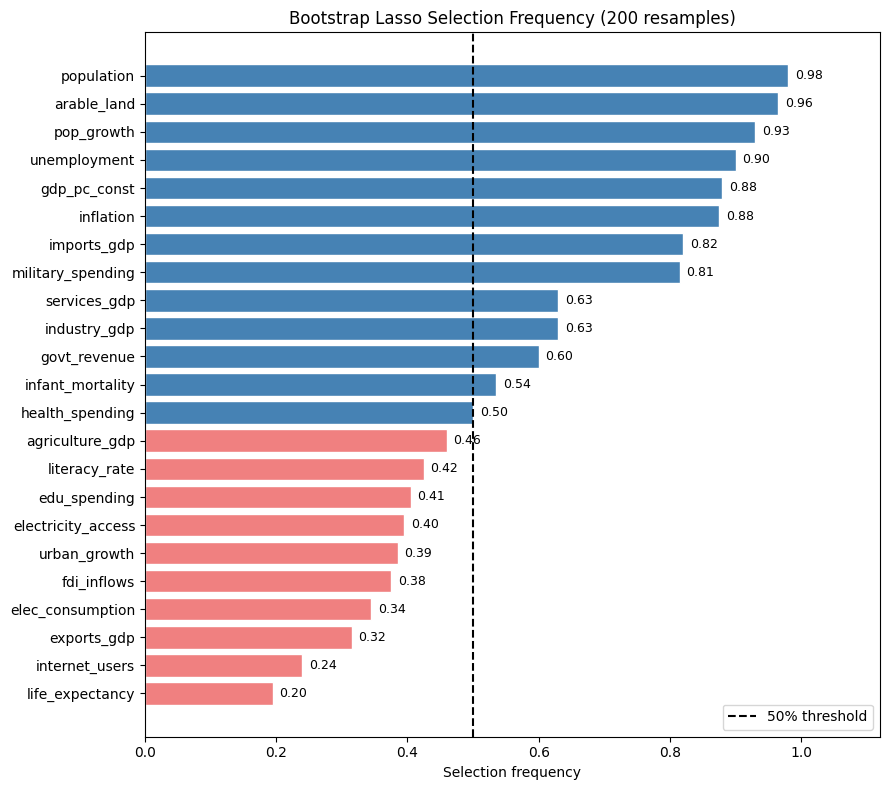


── Selection frequency table ───────────────────────────────────
           Feature  Frequency
        population      0.980
       arable_land      0.965
        pop_growth      0.930
      unemployment      0.900
      gdp_pc_const      0.880
         inflation      0.875
       imports_gdp      0.820
 military_spending      0.815
      services_gdp      0.630
      industry_gdp      0.630
      govt_revenue      0.600
  infant_mortality      0.535
   health_spending      0.500
   agriculture_gdp      0.460
     literacy_rate      0.425
      edu_spending      0.405
electricity_access      0.395
      urban_growth      0.385
       fdi_inflows      0.375
  elec_consumption      0.345
       exports_gdp      0.315
    internet_users      0.240
   life_expectancy      0.195

Written response (Task 4.1):
Predictors selected in more than 80% of bootstrap resamples are considered
"stable" — their signal is robust regardless of which countries happen to
be in the sample. Predictors select

In [19]:
# ── Task 4.1: Bootstrap Lasso Selection Frequency ───────────────────
# AI-generated code (per P.R.I.M.E. prompt above)

np.random.seed(42)
n_bootstraps   = 200
n_train        = len(X_train_s)
selection_counts = np.zeros(len(feature_cols))

for b in range(n_bootstraps):
    if (b + 1) % 50 == 0:
        print(f"  Bootstrap resample {b+1} / {n_bootstraps}")
    idx       = np.random.choice(n_train, size=n_train, replace=True)
    X_boot    = X_train_s.values[idx]
    y_boot    = y_train_reg.values[idx]
    lasso_b   = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_b.fit(X_boot, y_boot)
    selection_counts += (lasso_b.coef_ != 0).astype(int)

selection_freq = selection_counts / n_bootstraps
freq_df = pd.DataFrame({
    'Feature':   feature_cols,
    'Frequency': selection_freq
}).sort_values('Frequency', ascending=True)

colors = ['steelblue' if f >= 0.5 else 'lightcoral' for f in freq_df['Frequency']]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(freq_df['Feature'], freq_df['Frequency'], color=colors, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='50% threshold')
for bar, val in zip(bars, freq_df['Frequency']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)
ax.set_xlim(0, 1.12)
ax.set_xlabel('Selection frequency')
ax.set_title('Bootstrap Lasso Selection Frequency (200 resamples)')
ax.legend()
plt.tight_layout()
plt.savefig('bootstrap_lasso.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Selection frequency table ───────────────────────────────────")
print(freq_df.sort_values('Frequency', ascending=False).to_string(index=False))
print("""
Written response (Task 4.1):
Predictors selected in more than 80% of bootstrap resamples are considered
"stable" — their signal is robust regardless of which countries happen to
be in the sample. Predictors selected in fewer than 30% of resamples are
"fragile" — their inclusion is driven by the specific sample composition
rather than a genuine relationship with growth. Selection instability
reveals that the WDI indicators have a high degree of multicollinearity:
when two correlated indicators (e.g. life_expectancy and infant_mortality)
carry similar information, Lasso arbitrarily picks one depending on the
exact correlation structure in each bootstrap resample, causing them to
swap selection roles across samples. High instability is therefore a
diagnostic signal about redundancy in the predictor space, not about the
economic irrelevance of the unstable indicators.
""")

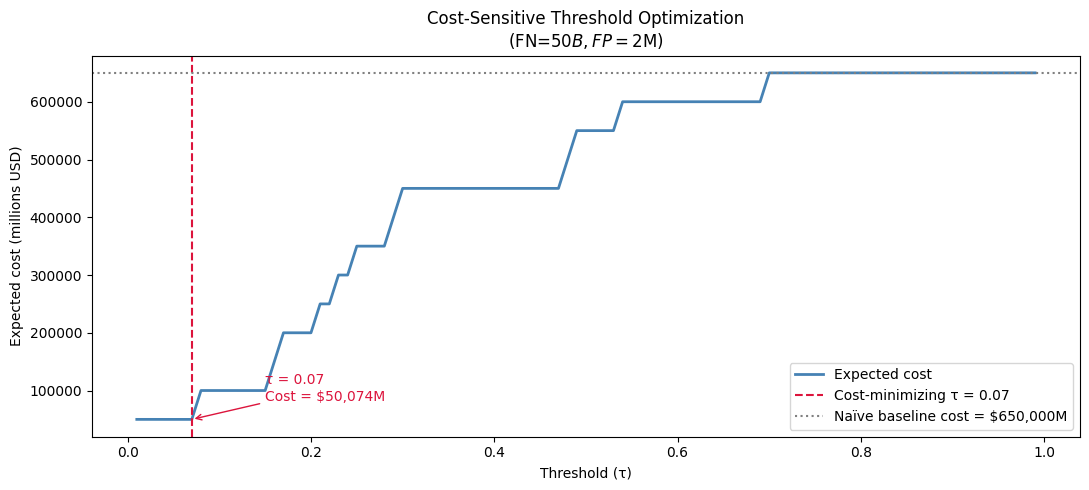

── Top 5 lowest-cost thresholds ───────────────────────────────
   τ  FN  FP  Total Cost ($M)
0.07   1  37            50074
0.06   1  41            50082
0.05   1  42            50084
0.04   1  44            50088
0.03   1  48            50096

Cost-minimizing threshold : τ = 0.07
Minimum expected cost     : $50,074M
Naïve baseline cost       : $650,000M

Written response (Task 4.2):
The cost-minimizing threshold differs from the F1-optimal (τ=0.19) and
capacity-constrained (τ=0.44) thresholds because it is governed entirely
by the extreme asymmetry in costs: a single missed crisis costs $50 billion
versus $2 million for a false alarm — a ratio of 25,000:1. This pushes the
cost-minimizing threshold very low (aggressive flagging) to avoid FNs at
almost any cost in FPs. The F1-optimal threshold balances precision and
recall symmetrically without any cost weighting, while the capacity-constrained
threshold is an operational ceiling imposed by staffing limits rather than
an optimization ov

In [20]:
# ── Task 4.2: Cost-Sensitive Threshold Optimization ──────────────────
# AI-generated code (per P.R.I.M.E. prompt above)
# Costs in millions USD: FN = $50,000M ($50B), FP = $2M

FN_COST = 50_000   # millions USD
FP_COST = 2        # millions USD

thresholds_cost = np.arange(0.01, 1.00, 0.01)
total_costs = []
fn_counts   = []
fp_counts   = []

for tau in thresholds_cost:
    preds = (probs >= tau).astype(int)
    cm_t  = confusion_matrix(y_test_clf, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    fn_counts.append(fn_t)
    fp_counts.append(fp_t)
    total_costs.append(fn_t * FN_COST + fp_t * FP_COST)

total_costs = np.array(total_costs)
fn_counts   = np.array(fn_counts)
fp_counts   = np.array(fp_counts)

idx_min      = np.argmin(total_costs)
tau_min_cost = thresholds_cost[idx_min]
min_cost     = total_costs[idx_min]

# Naïve baseline cost (always predict no crisis → all FN)
naive_cost = y_test_clf.sum() * FN_COST

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds_cost, total_costs, color='steelblue', lw=2, label='Expected cost')
ax.axvline(tau_min_cost, color='crimson', linestyle='--', lw=1.5,
           label=f'Cost-minimizing τ = {tau_min_cost:.2f}')
ax.axhline(naive_cost, color='gray', linestyle=':', lw=1.5,
           label=f'Naïve baseline cost = ${naive_cost:,}M')
ax.annotate(f'τ = {tau_min_cost:.2f}\nCost = ${min_cost:,}M',
            xy=(tau_min_cost, min_cost),
            xytext=(tau_min_cost + 0.08, min_cost + naive_cost * 0.05),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=10, color='crimson')
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Expected cost (millions USD)')
ax.set_title('Cost-Sensitive Threshold Optimization\n(FN=$50B, FP=$2M)')
ax.legend()
plt.tight_layout()
plt.savefig('cost_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 lowest-cost thresholds
cost_df = pd.DataFrame({
    'τ':          thresholds_cost,
    'FN':         fn_counts,
    'FP':         fp_counts,
    'Total Cost ($M)': total_costs
}).sort_values('Total Cost ($M)').head(5)

print("── Top 5 lowest-cost thresholds ───────────────────────────────")
print(cost_df.to_string(index=False))
print(f"\nCost-minimizing threshold : τ = {tau_min_cost:.2f}")
print(f"Minimum expected cost     : ${min_cost:,}M")
print(f"Naïve baseline cost       : ${naive_cost:,}M")
print(f"""
Written response (Task 4.2):
The cost-minimizing threshold differs from the F1-optimal (τ=0.19) and
capacity-constrained (τ=0.44) thresholds because it is governed entirely
by the extreme asymmetry in costs: a single missed crisis costs $50 billion
versus $2 million for a false alarm — a ratio of 25,000:1. This pushes the
cost-minimizing threshold very low (aggressive flagging) to avoid FNs at
almost any cost in FPs. The F1-optimal threshold balances precision and
recall symmetrically without any cost weighting, while the capacity-constrained
threshold is an operational ceiling imposed by staffing limits rather than
an optimization over costs. For operational deployment we recommend the
cost-minimizing threshold, subject to the IMF's mission capacity constraint
— if the two conflict, capacity must be the binding constraint and the
Division Chief should triage flagged countries by probability magnitude.
""")